In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


AT = Temperature ,
v = vaccum ,
AP = pressure ,
RH = humidity

PE = produce Energy

In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
df.shape

(9568, 5)

In [6]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [7]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [8]:
# split  out data
from sklearn.model_selection import train_test_split
X_train , X_test ,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [9]:
# scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [11]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)
# .view(-1,1) change the dim
X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)
# This tensor store is the RAM

In [12]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [13]:
train_loader = DataLoader(train_dataset, batch_size = 32 , shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 32)

Deep Learning

In [21]:
# build our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
          # 1st hidden layer
          nn.Linear(X_train.shape[1],6),
          nn.ReLU(),

          # 2nd Hidden Layer
          nn.Linear(6,6),
          nn.ReLU(),

          # Output Layer
          nn.Linear(6,1),
        )

    def forward(self,x):
        return self.model(x)

In [22]:
import torch.optim as optim
model = ANN()
#loss , Optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [23]:
# train the ANN
train_losses = []
val_losses = []
best_val_loss = float("inf")
epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = featurs of one batch
        # yb = labels of oen batch
        optimizer.zero_grad()
        outputs = model(xb) # forward prop ... predicted outputs for this batch
        loss = crietrion(outputs,yb) # compute loss
        loss.backward() # back prop .. compute gradients
        optimizer.step() # parameter update
        running_loss += loss.item() # loss is a tensor => python float


    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs,yb)
            
            running_val_loss += loss
        epoch_val_loss = running_val_loss / len(test_loader)
        val_losses.append(epoch_val_loss)

        print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss => {epoch_val_loss}")
            
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(),"best_model.pt") # .pt , .pth

epoch 1/100 ==> train loss = 206749.32630208333 & val loss => 205850.078125
epoch 2/100 ==> train loss = 203732.0869140625 & val loss => 199963.171875
epoch 3/100 ==> train loss = 192886.6119140625 & val loss => 183445.71875
epoch 4/100 ==> train loss = 170069.92415364584 & val loss => 154956.09375
epoch 5/100 ==> train loss = 136645.77682291667 & val loss => 115543.59375
epoch 6/100 ==> train loss = 90640.64095052083 & val loss => 68441.71875
epoch 7/100 ==> train loss = 52087.30620117187 & val loss => 40067.73828125
epoch 8/100 ==> train loss = 32626.54558919271 & val loss => 27420.263671875
epoch 9/100 ==> train loss = 23911.812756347656 & val loss => 21263.12109375
epoch 10/100 ==> train loss = 19385.255000813802 & val loss => 17666.982421875
epoch 11/100 ==> train loss = 16335.064998372396 & val loss => 14836.7880859375
epoch 12/100 ==> train loss = 13660.453338623047 & val loss => 12183.7744140625
epoch 13/100 ==> train loss = 11033.974401855468 & val loss => 9606.1201171875
epoc

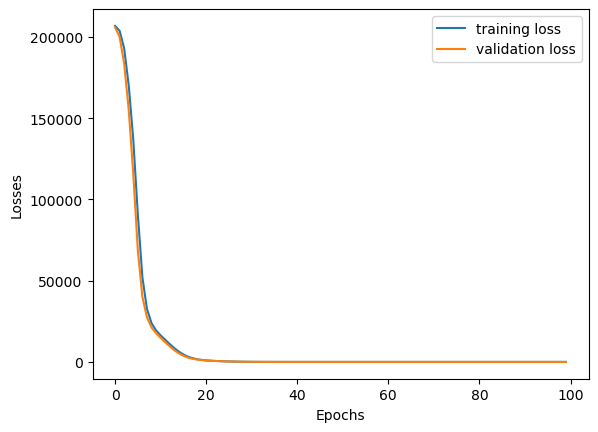

In [24]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "train_loss":train_losses,
    "val_loss": val_losses
})
plt.plot(loss_df["train_loss"],label = "training loss")
plt.plot(loss_df["val_loss"],label = "validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [25]:
# Loadind the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [28]:
# Evaluate our model
model.eval()
with torch.no_grad():
    train_preds =model(X_train_tensor)
    test_preds =model(X_test_tensor)

    train_mse_loss = crietrion(train_preds,X_train_tensor)
    test_mse_loss = crietrion(test_preds,X_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 206574.546875
Testing MSE: 206697.359375


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([7654, 4])) that is different to the input size (torch.Size([7654, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([1914, 4])) that is different to the input size (torch.Size([1914, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [29]:
from sklearn.metrics import r2_score
print("r2_score = ",r2_score(y_test,test_preds))

r2_score =  0.9314077671834428


In [30]:
predicted_df = pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])
pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,435.934113,433.27
1,437.324768,438.16
2,461.197571,458.42
3,475.781433,480.82
4,435.937683,441.41
...,...,...
1909,451.443787,456.70
1910,432.218933,438.04
1911,467.645782,467.80
1912,431.656067,437.14
